# __Titanic Survival Prediction__

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.shape

(891, 15)

__Data Cleaning & Dealing with Missing Data__

In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
df.drop(columns='deck', inplace=True)
df.shape

(891, 14)

In [7]:

df["age"].fillna(df["age"].median(), inplace=True)

C:\Users\baigs\AppData\Local\Temp\ipykernel_11280\2641532153.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


In [8]:
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

C:\Users\baigs\AppData\Local\Temp\ipykernel_11280\3995229981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)


In [9]:
df['embark_town'] = df.embark_town.fillna(value= df['embark_town'].mode()[0])

In [10]:
df.shape

(891, 14)

In [11]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

__Removing Duplicate Data__

In [12]:
df.duplicated().sum()

116

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

___Removing Outliers___

<Axes: >

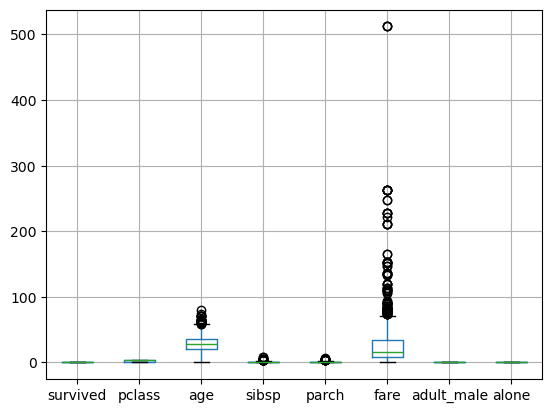

In [15]:
df.boxplot()

In [22]:
sns.boxplot(data=df, y='age')

<Axes: ylabel='age'>

In [17]:
df.boxplot(column='fare')

<Axes: ylabel='age'>

In [18]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

In [19]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['fare'] >= lower_bound) & (df['fare'] <= upper_bound)]

___Features and Target___

In [ ]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[features]
y = df["survived"]

In [ ]:
# Encoding categorical variables
X = pd.get_dummies(X, columns=["sex", "embarked"], drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


___Feature Scaling___

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

___Logistic Regression___

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

In [ ]:
print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


===== Logistic Regression =====
Accuracy: 0.7461538461538462
Precision: 0.7254901960784313
Recall: 0.6607142857142857
F1 Score: 0.6915887850467289
Confusion Matrix:
 [[60 14]
 [19 37]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.78        74
           1       0.73      0.66      0.69        56

    accuracy                           0.75       130
   macro avg       0.74      0.74      0.74       130
weighted avg       0.74      0.75      0.74       130



___Decision Tree___

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
print("\n===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


===== Decision Tree =====
Accuracy: 0.7307692307692307
Precision: 0.6842105263157895
Recall: 0.6964285714285714
F1 Score: 0.6902654867256637
Confusion Matrix:
 [[56 18]
 [17 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.76      0.76        74
           1       0.68      0.70      0.69        56

    accuracy                           0.73       130
   macro avg       0.73      0.73      0.73       130
weighted avg       0.73      0.73      0.73       130



___Random Forest___

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


===== Random Forest =====
Accuracy: 0.7692307692307693
Precision: 0.76
Recall: 0.6785714285714286
F1 Score: 0.7169811320754716
Confusion Matrix:
 [[62 12]
 [18 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81        74
           1       0.76      0.68      0.72        56

    accuracy                           0.77       130
   macro avg       0.77      0.76      0.76       130
weighted avg       0.77      0.77      0.77       130



____Cross Validation (Random Forest)____

In [ ]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

print("CV Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

CV Scores: [0.71538462 0.72307692 0.76923077 0.76923077 0.78294574]
Average CV Accuracy: 0.7519737626714371
